# 05 - Monitoring de drift avec Evidently

Objectif : repondre a la question du CDO : **Comment saurai-je que le modele se degrade dans 3 mois ?**

Ce notebook met en place un scenario de monitoring :

- decoupage temporel en T0 / T1 / T2 ;
- entrainement du modele sur T0 ;
- evaluation sur T1, periode de production stable ;
- simulation d'une evolution des patterns frauduleux sur T2 ;
- comparaison T1 vs T2 ;
- generation de rapports HTML Evidently ;
- definition de seuils d'alerte de retraining.


## 0. Installation et imports

Evidently change souvent d'API. Pour ce notebook, la version legacy suivante est recommandee :

```bash
pip install evidently==0.4.40
```

Autres dependances :

```bash
pip install polars pyarrow pandas numpy matplotlib seaborn scikit-learn xgboost
```


In [1]:
from pathlib import Path
import gc
import json
import time
import warnings

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, f1_score, precision_score, recall_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42
DATA_DIR = Path("data") if Path("data").exists() else Path("../data")
PROJECT_ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
REPORTS_DIR = PROJECT_ROOT / "evidently_reports"
ASSETS_DIR = PROJECT_ROOT / "docs" / "assets"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
ASSETS_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_TRANSACTION_PATH = DATA_DIR / "train_transaction.csv"
TRAIN_IDENTITY_PATH = DATA_DIR / "train_identity.csv"

for path in [TRAIN_TRANSACTION_PATH, TRAIN_IDENTITY_PATH]:
    if not path.exists():
        raise FileNotFoundError(f"Fichier introuvable : {path.resolve()}")


def save_plot(filename):
    output_path = ASSETS_DIR / filename
    plt.savefig(output_path, dpi=160, bbox_inches="tight")
    print(f"Figure sauvegardee : {output_path}")


## 1. Configuration

On utilise un decoupage temporel simple :

- **T0** : apprentissage, jours 1 a 120 ;
- **T1** : production stable, jours 121 a 150 ;
- **T2** : production apres evolution des patterns, jours 151 a 182.

Le drift est simule en transformant une partie des fraudes de T2 en micro-transactions de faible montant. L'objectif est de representer une tactique de fraude qui evolue vers des petits paiements fragmentes.


In [2]:
T0_MAX_DAY = 120
T1_MAX_DAY = 150
DECISION_THRESHOLD = 0.25
DRIFT_FRAUD_MICRO_AMOUNT_MAX = 35.0
DRIFT_FRAUD_SHARE_TO_MODIFY = 0.70

AUPRC_DROP_ALERT_THRESHOLD = 0.15
PSI_ALERT_THRESHOLD = 0.20
SCORE_MEAN_SHIFT_ALERT_THRESHOLD = 0.20

BASE_XGB_PARAMS = dict(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)


## 2. Chargement et feature engineering

On reconstruit les memes features compactes que dans la modelisation : variables transactionnelles, categories principales et features de velocite 1h / 24h / 7j.


In [3]:
start = time.time()

train = (
    pl.scan_csv(TRAIN_TRANSACTION_PATH)
    .join(pl.scan_csv(TRAIN_IDENTITY_PATH), on="TransactionID", how="left")
    .sort("TransactionDT")
    .collect()
)

SECONDS_PER_HOUR = 3600
SECONDS_PER_DAY = 24 * SECONDS_PER_HOUR
SECONDS_PER_WEEK = 7 * SECONDS_PER_DAY

train = train.with_columns([
    (pl.col("TransactionDT") // SECONDS_PER_HOUR).cast(pl.Int64).alias("hour_rel"),
    (pl.col("TransactionDT") // SECONDS_PER_DAY).cast(pl.Int64).alias("day_rel"),
    (pl.col("TransactionDT") // SECONDS_PER_WEEK).cast(pl.Int64).alias("week_rel"),
    ((pl.col("TransactionDT") // SECONDS_PER_HOUR) % 24).cast(pl.Int64).alias("hour_of_day_rel"),
])

print(f"Dataset charge : {train.shape}")
print(f"Temps : {time.time() - start:.1f} secondes")


Dataset charge : (590540, 438)
Temps : 183.0 secondes


In [4]:
id_cols = [col for col in ["card1", "card2", "card3", "card5", "addr1"] if col in train.columns]
merchant_cols = [col for col in ["ProductCD", "R_emaildomain"] if col in train.columns]

WINDOW_SPECS = {
    "1h": 60 * 60,
    "24h": 24 * 60 * 60,
    "7d": 7 * 24 * 60 * 60,
}

train = (
    train
    .with_row_count("txn_row_id")
    .with_columns([
        pl.concat_str([pl.col(c).cast(pl.Utf8).fill_null("missing") for c in id_cols], separator="_").alias("customer_proxy"),
        pl.concat_str([pl.col(c).cast(pl.Utf8).fill_null("missing") for c in merchant_cols], separator="_").alias("merchant_proxy"),
    ])
    .sort(["customer_proxy", "TransactionDT", "txn_row_id"])
    .with_columns([
        pl.cum_count("TransactionID").over("customer_proxy").alias("customer_tx_count_cum"),
        pl.col("TransactionAmt").cum_sum().over("customer_proxy").alias("customer_amt_cumsum"),
        pl.cum_count("TransactionID").over(["customer_proxy", "merchant_proxy"]).sub(1).alias("merchant_seen_count_prev"),
    ])
    .with_columns([
        pl.col("customer_tx_count_cum").sub(1).alias("customer_tx_count_prev"),
        (pl.col("customer_amt_cumsum") - pl.col("TransactionAmt")).alias("customer_amt_sum_prev"),
    ])
    .with_columns([
        pl.when(pl.col("customer_tx_count_prev") > 0)
        .then(pl.col("customer_amt_sum_prev") / pl.col("customer_tx_count_prev"))
        .otherwise(None)
        .alias("customer_amt_mean_prev"),
        (pl.col("merchant_seen_count_prev") == 0).cast(pl.Int8).alias("is_new_merchant_for_customer"),
    ])
    .with_columns([
        pl.when(pl.col("customer_tx_count_prev") > 0)
        .then(pl.col("TransactionAmt") / pl.col("customer_amt_mean_prev"))
        .otherwise(None)
        .alias("amt_to_customer_mean_prev"),
    ])
)

history_lookup = train.select([
    "customer_proxy",
    "TransactionDT",
    "customer_tx_count_cum",
    "customer_amt_cumsum",
]).sort("TransactionDT")

helper_cols_to_drop = ["customer_tx_count_cum", "customer_amt_cumsum"]
window_features = []

for label, seconds in WINDOW_SPECS.items():
    before_count_col = f"customer_tx_count_before_{label}"
    before_sum_col = f"customer_amt_sum_before_{label}"
    count_col = f"customer_tx_count_prev_{label}"
    sum_col = f"customer_amt_sum_prev_{label}"

    cutoff_points = (
        train
        .select([
            "txn_row_id",
            "customer_proxy",
            (pl.col("TransactionDT") - seconds).alias("window_start_dt"),
        ])
        .sort("window_start_dt")
    )

    window_start_history = (
        cutoff_points
        .join_asof(
            history_lookup,
            left_on="window_start_dt",
            right_on="TransactionDT",
            by="customer_proxy",
            strategy="backward",
        )
        .select([
            "txn_row_id",
            pl.col("customer_tx_count_cum").fill_null(0).alias(before_count_col),
            pl.col("customer_amt_cumsum").fill_null(0.0).alias(before_sum_col),
        ])
    )

    train = (
        train
        .join(window_start_history, on="txn_row_id", how="left")
        .with_columns([
            pl.max_horizontal([
                pl.col("customer_tx_count_prev") - pl.col(before_count_col),
                pl.lit(0),
            ]).alias(count_col),
            pl.max_horizontal([
                pl.col("customer_amt_sum_prev") - pl.col(before_sum_col),
                pl.lit(0.0),
            ]).alias(sum_col),
        ])
    )

    window_features.extend([count_col, sum_col])
    helper_cols_to_drop.extend([before_count_col, before_sum_col])

engineered_features = [
    "customer_tx_count_prev",
    "customer_amt_mean_prev",
    "amt_to_customer_mean_prev",
    "is_new_merchant_for_customer",
] + window_features

train = train.drop(helper_cols_to_drop).sort("txn_row_id")
print(engineered_features)


['customer_tx_count_prev', 'customer_amt_mean_prev', 'amt_to_customer_mean_prev', 'is_new_merchant_for_customer', 'customer_tx_count_prev_1h', 'customer_amt_sum_prev_1h', 'customer_tx_count_prev_24h', 'customer_amt_sum_prev_24h', 'customer_tx_count_prev_7d', 'customer_amt_sum_prev_7d']


## 3. Preparation tabulaire et splits T0 / T1 / T2

On conserve le set compact de features, puis on cree les trois periodes temporelles.


In [5]:
compact_numeric_candidates = [
    "TransactionAmt",
    "card1", "card2", "card3", "card5",
    "addr1", "addr2", "dist1", "dist2",
    "C1", "C2", "C3", "C4", "C5", "C6", "C7", "C8", "C9", "C10", "C11", "C12", "C13", "C14",
    "D1", "D2", "D3", "D4", "D5", "D10", "D15",
    "hour_rel", "day_rel", "week_rel", "hour_of_day_rel",
]

numeric_features = [col for col in compact_numeric_candidates if col in train.columns]

candidate_categorical_features = [
    "ProductCD", "card4", "card6", "P_emaildomain", "R_emaildomain",
    "DeviceType", "id_12", "id_15", "id_16", "id_28", "id_29",
    "id_35", "id_36", "id_37", "id_38",
]
categorical_features = [col for col in candidate_categorical_features if col in train.columns]
feature_cols = list(dict.fromkeys(numeric_features + categorical_features + engineered_features))
model_columns = list(dict.fromkeys(feature_cols + ["isFraud", "day_rel", "TransactionID"]))

model_pd = train.select(model_columns).to_pandas()
del train
gc.collect()

t0 = model_pd[model_pd["day_rel"] <= T0_MAX_DAY].copy()
t1 = model_pd[(model_pd["day_rel"] > T0_MAX_DAY) & (model_pd["day_rel"] <= T1_MAX_DAY)].copy()
t2 = model_pd[model_pd["day_rel"] > T1_MAX_DAY].copy()

split_summary = pd.DataFrame([
    {"period": "T0_train", "rows": len(t0), "day_min": t0.day_rel.min(), "day_max": t0.day_rel.max(), "fraud_rate": t0.isFraud.mean()},
    {"period": "T1_stable", "rows": len(t1), "day_min": t1.day_rel.min(), "day_max": t1.day_rel.max(), "fraud_rate": t1.isFraud.mean()},
    {"period": "T2_drift", "rows": len(t2), "day_min": t2.day_rel.min(), "day_max": t2.day_rel.max(), "fraud_rate": t2.isFraud.mean()},
])
display(split_summary)
print(f"Features : {len(feature_cols)}")


,period,rows,day_min,day_max,fraud_rate
0,T0_train,414542,1,120,0.0352
1,T1_stable,83571,121,150,0.0341
2,T2_drift,92427,151,182,0.0348


Features : 59


## 4. Simulation du drift T2

On simule une evolution des fraudeurs : une partie des fraudes de T2 devient des micro-transactions de faible montant. On modifie aussi le ratio comportemental associe au montant pour que le drift soit visible dans les features.


In [6]:
rng = np.random.default_rng(RANDOM_STATE)
t2_drifted = t2.copy()
fraud_idx = t2_drifted[t2_drifted["isFraud"] == 1].index.to_numpy()
n_to_modify = int(len(fraud_idx) * DRIFT_FRAUD_SHARE_TO_MODIFY)
modified_idx = rng.choice(fraud_idx, size=n_to_modify, replace=False)

new_amounts = rng.uniform(1.0, DRIFT_FRAUD_MICRO_AMOUNT_MAX, size=n_to_modify)
old_amounts = t2_drifted.loc[modified_idx, "TransactionAmt"].to_numpy()
t2_drifted.loc[modified_idx, "TransactionAmt"] = new_amounts

# Ajustement simple des features derivees du montant.
if "amt_to_customer_mean_prev" in t2_drifted.columns:
    denom = t2_drifted.loc[modified_idx, "customer_amt_mean_prev"].replace(0, np.nan)
    t2_drifted.loc[modified_idx, "amt_to_customer_mean_prev"] = new_amounts / denom

for col in ["customer_amt_sum_prev_1h", "customer_amt_sum_prev_24h", "customer_amt_sum_prev_7d"]:
    if col in t2_drifted.columns:
        t2_drifted.loc[modified_idx, col] = np.maximum(
            0,
            t2_drifted.loc[modified_idx, col].to_numpy() - old_amounts + new_amounts,
        )

print(f"Fraudes T2 modifiees : {n_to_modify} / {len(fraud_idx)}")
display(t2[["TransactionAmt", "isFraud"]].groupby("isFraud").describe())
display(t2_drifted[["TransactionAmt", "isFraud"]].groupby("isFraud").describe())


Fraudes T2 modifiees : 2249 / 3213


TransactionAmt                                                    \
                 count     mean      std    min     25%     50%      75%   
isFraud                                                                    
0          89,214.0000 137.1885 246.9916 0.4990 44.0000 68.9500 117.0000   
1           3,213.0000 151.7156 254.0069 2.2310 32.2770 62.5870 150.0000   

                    
               max  
isFraud             
0       5,366.8200  
1       3,133.0600

TransactionAmt                                                    \
                 count     mean      std    min     25%     50%      75%   
isFraud                                                                    
0          89,214.0000 137.1885 246.9916 0.4990 44.0000 68.9500 117.0000   
1           3,213.0000  57.3511 154.1688 1.0218 11.8115 22.4637  33.2370   

                    
               max  
isFraud             
0       5,366.8200  
1       3,133.0600

## 5. Entrainement T0 et evaluation T1 / T2

Le modele est entraine sur T0, puis evalue sur T1 et T2 drifted.


In [7]:
X_t0 = t0[feature_cols]
y_t0 = t0["isFraud"].astype(int)
X_t1 = t1[feature_cols]
y_t1 = t1["isFraud"].astype(int)
X_t2 = t2_drifted[feature_cols]
y_t2 = t2_drifted["isFraud"].astype(int)

numeric_features_final = X_t0.select_dtypes(include=[np.number]).columns.tolist()
categorical_features_final = [col for col in feature_cols if col not in numeric_features_final]

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), numeric_features_final),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
        ]), categorical_features_final),
    ],
    remainder="drop",
)

X_t0_p = preprocess.fit_transform(X_t0)
X_t1_p = preprocess.transform(X_t1)
X_t2_p = preprocess.transform(X_t2)

model = XGBClassifier(**BASE_XGB_PARAMS)
model.fit(X_t0_p, y_t0.to_numpy())

score_t1 = model.predict_proba(X_t1_p)[:, 1]
score_t2 = model.predict_proba(X_t2_p)[:, 1]

def perf_row(period, y_true, scores):
    preds = (scores >= DECISION_THRESHOLD).astype(int)
    return {
        "period": period,
        "AUPRC": average_precision_score(y_true, scores),
        "precision": precision_score(y_true, preds, zero_division=0),
        "recall": recall_score(y_true, preds, zero_division=0),
        "F1": f1_score(y_true, preds, zero_division=0),
        "alert_rate": preds.mean(),
        "score_mean": scores.mean(),
        "score_p95": np.quantile(scores, 0.95),
    }

performance_df = pd.DataFrame([
    perf_row("T1_stable", y_t1, score_t1),
    perf_row("T2_drifted", y_t2, score_t2),
])

auprc_t1 = performance_df.loc[performance_df.period == "T1_stable", "AUPRC"].iloc[0]
auprc_t2 = performance_df.loc[performance_df.period == "T2_drifted", "AUPRC"].iloc[0]
performance_df["AUPRC_drop_vs_T1"] = [0.0, (auprc_t1 - auprc_t2) / auprc_t1]

display(performance_df)


,period,AUPRC,precision,recall,F1,alert_rate,score_mean,score_p95,AUPRC_drop_vs_T1
0,T1_stable,0.4873,0.6024,0.3933,0.4759,0.0223,0.0355,0.1140,0.0000
1,T2_drifted,0.4464,0.5666,0.3934,0.4644,0.0241,0.0380,0.1251,0.0840


## 6. Graphiques de drift et performance

Ces graphes sont sauvegardes dans `docs/assets/`.


Figure sauvegardee : /mnt/c/Users/tanjo/projetcs/fraud-scope/docs/assets/05_drift_amount_scores.png


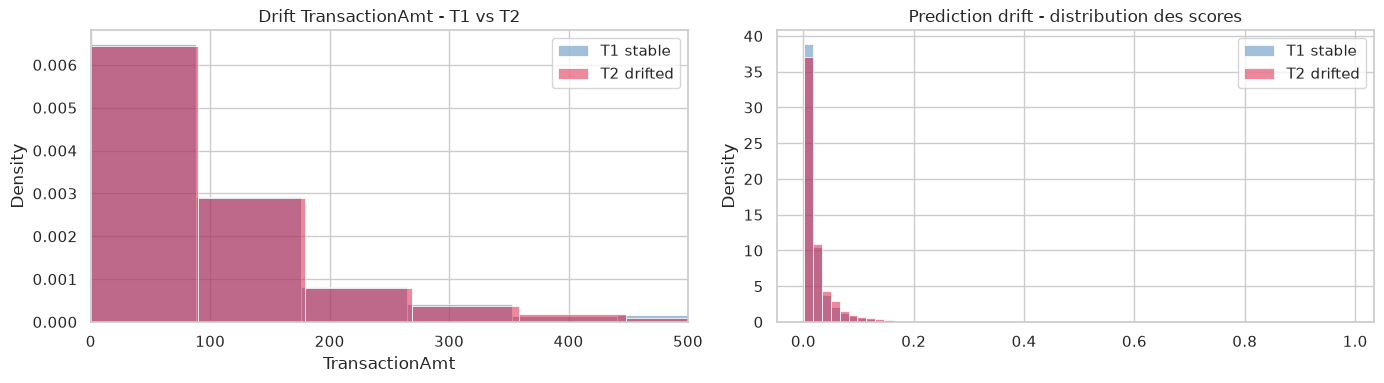

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(t1["TransactionAmt"], bins=60, stat="density", label="T1 stable", color="steelblue", alpha=0.5, ax=axes[0])
sns.histplot(t2_drifted["TransactionAmt"], bins=60, stat="density", label="T2 drifted", color="crimson", alpha=0.5, ax=axes[0])
axes[0].set_xlim(0, 500)
axes[0].set_title("Drift TransactionAmt - T1 vs T2")
axes[0].legend()

sns.histplot(score_t1, bins=60, stat="density", label="T1 stable", color="steelblue", alpha=0.5, ax=axes[1])
sns.histplot(score_t2, bins=60, stat="density", label="T2 drifted", color="crimson", alpha=0.5, ax=axes[1])
axes[1].set_title("Prediction drift - distribution des scores")
axes[1].legend()

plt.tight_layout()
save_plot("05_drift_amount_scores.png")
plt.show()


Figure sauvegardee : /mnt/c/Users/tanjo/projetcs/fraud-scope/docs/assets/05_model_performance_drift.png


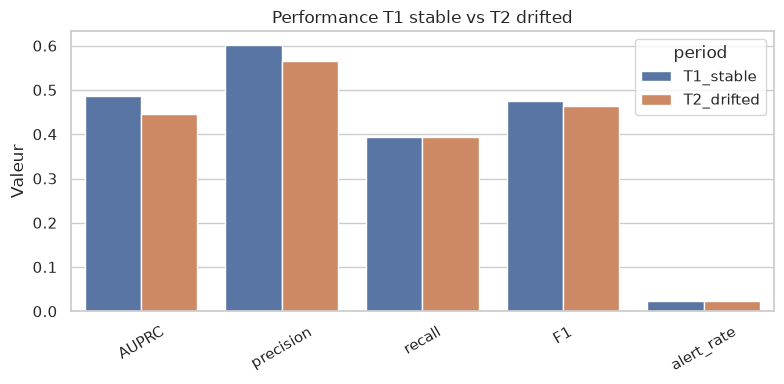

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_df = performance_df.melt(id_vars="period", value_vars=["AUPRC", "precision", "recall", "F1", "alert_rate"])
sns.barplot(data=plot_df, x="variable", y="value", hue="period", ax=ax)
ax.set_title("Performance T1 stable vs T2 drifted")
ax.set_xlabel("")
ax.set_ylabel("Valeur")
plt.xticks(rotation=30)
plt.tight_layout()
save_plot("05_model_performance_drift.png")
plt.show()


## 7. Rapports Evidently

Cette cellule genere les rapports HTML Evidently. Si l'API Evidently n'est pas disponible, installe `evidently==0.4.40`.


In [10]:
reference_df = t1[feature_cols + ["isFraud"]].copy()
current_df = t2_drifted[feature_cols + ["isFraud"]].copy()
reference_df["prediction"] = score_t1
current_df["prediction"] = score_t2

try:
    from evidently.report import Report
    from evidently.metric_preset import DataDriftPreset, ClassificationPreset, TargetDriftPreset
    from evidently.pipeline.column_mapping import ColumnMapping

    column_mapping = ColumnMapping()
    column_mapping.target = "isFraud"
    column_mapping.prediction = "prediction"
    column_mapping.numerical_features = numeric_features_final
    column_mapping.categorical_features = categorical_features_final

    data_drift_report = Report(metrics=[DataDriftPreset()])
    data_drift_report.run(reference_data=reference_df, current_data=current_df, column_mapping=column_mapping)
    data_drift_path = REPORTS_DIR / "data_drift_report.html"
    data_drift_report.save_html(str(data_drift_path))

    model_perf_report = Report(metrics=[ClassificationPreset()])
    model_perf_report.run(reference_data=reference_df, current_data=current_df, column_mapping=column_mapping)
    model_perf_path = REPORTS_DIR / "model_performance_report.html"
    model_perf_report.save_html(str(model_perf_path))

    prediction_drift_report = Report(metrics=[TargetDriftPreset()])
    prediction_drift_report.run(reference_data=reference_df, current_data=current_df, column_mapping=column_mapping)
    prediction_drift_path = REPORTS_DIR / "prediction_drift_report.html"
    prediction_drift_report.save_html(str(prediction_drift_path))

    print("Rapports Evidently generes :")
    print(data_drift_path)
    print(model_perf_path)
    print(prediction_drift_path)
except Exception as exc:
    print("Evidently n'a pas pu generer les rapports avec l'API legacy.")
    print("Installe de preference : pip install evidently==0.4.40")
    print(type(exc).__name__, exc)


Rapports Evidently generes :
/mnt/c/Users/tanjo/projetcs/fraud-scope/evidently_reports/data_drift_report.html
/mnt/c/Users/tanjo/projetcs/fraud-scope/evidently_reports/model_performance_report.html
/mnt/c/Users/tanjo/projetcs/fraud-scope/evidently_reports/prediction_drift_report.html


## 8. Seuils d'alerte et decision de retraining

On applique des seuils simples :

- alerte si l'AUPRC chute de plus de 15 % ;
- alerte si la moyenne des scores change de plus de 20 % ;
- alerte si PSI > 0.2 sur une feature critique.


In [12]:
score_mean_shift = float(abs(score_t2.mean() - score_t1.mean()) / max(score_t1.mean(), 1e-9))
auprc_drop = float((auprc_t1 - auprc_t2) / auprc_t1)
max_psi = float(psi_df["PSI"].max()) if len(psi_df) else 0.0

alert_report = {
    "AUPRC_T1": float(auprc_t1),
    "AUPRC_T2": float(auprc_t2),
    "AUPRC_drop": auprc_drop,
    "AUPRC_drop_alert": bool(auprc_drop > AUPRC_DROP_ALERT_THRESHOLD),
    "score_mean_T1": float(score_t1.mean()),
    "score_mean_T2": float(score_t2.mean()),
    "score_mean_shift": score_mean_shift,
    "score_shift_alert": bool(score_mean_shift > SCORE_MEAN_SHIFT_ALERT_THRESHOLD),
    "max_PSI": max_psi,
    "PSI_alert": bool(max_psi > PSI_ALERT_THRESHOLD),
}

alert_report["retraining_alert"] = bool(any([
    alert_report["AUPRC_drop_alert"],
    alert_report["score_shift_alert"],
    alert_report["PSI_alert"],
]))

display(pd.Series(alert_report).to_frame("monitoring_decision"))

monitoring_summary_path = PROJECT_ROOT / "docs" / "monitoring_drift_summary.json"
monitoring_summary_path.write_text(json.dumps(alert_report, indent=2))
performance_df.to_csv(PROJECT_ROOT / "docs" / "monitoring_performance.csv", index=False)
psi_df.to_csv(PROJECT_ROOT / "docs" / "monitoring_psi.csv", index=False)
print(f"Resume sauvegarde : {monitoring_summary_path}")

,monitoring_decision
AUPRC_T1,0.4873
AUPRC_T2,0.4464
AUPRC_drop,0.0840
AUPRC_drop_alert,False
score_mean_T1,0.0355
score_mean_T2,0.0380
score_mean_shift,0.0723
score_shift_alert,False
max_PSI,0.0033
PSI_alert,False


Resume sauvegarde : /mnt/c/Users/tanjo/projetcs/fraud-scope/docs/monitoring_drift_summary.json


## 9. Conclusion a reporter

A completer apres execution :

- comparer l'AUPRC T1 et T2 ;
- citer les features avec PSI eleve ;
- indiquer si l'alerte de retraining est declenchee ;
- expliquer a quelle date/periode il aurait fallu reentrainer.

Formulation possible :

> Le modele doit etre surveille en production via la derive des donnees, la derive des scores et la performance sur labels retardes. Dans notre simulation, si l'AUPRC chute de plus de 15 % ou si une feature critique depasse PSI 0.2, une alerte de retraining est declenchee.
